### Convolution

As mentioned in the previous notebook, `fvdb.nn` contains useful Modules such as the convolutional layer `SparseConv3d` which operates with `ConvolutionPlan` objects and `JaggedTensor` inputs.

In [2]:
import numpy as np
import torch
import fvdb
import tqdm

from fvdb import ConvolutionPlan
from fvdb.nn import SparseConv3d, SparseConvTranspose3d

batch_size = 8
num_voxels_per_grid = [np.random.randint(1_000, 10_000) for _ in range(batch_size)]

# A list of randomly generated 3D indices for each grid in our batch in the range [-512, 512]
ijks = [torch.randint(-512, 512, (num_voxels_per_grid[i], 3), device="cuda") for i in range(batch_size)]

# ijks is currently a list of tensors, we need to convert it to a JaggedTensor
jagged_ijks = fvdb.JaggedTensor(ijks)

grid_batch = fvdb.GridBatch.from_ijk(jagged_ijks)

# Some random features of 8 channels for each voxel in the grid
features = grid_batch.jagged_like(torch.randn(grid_batch.total_voxels, 8, device=grid_batch.device))

# SparseConv3d of 8 -> 16 features
conv_layer = SparseConv3d(8, 16, kernel_size=3, stride=1).to("cuda")

# Restrict stride=1 convolution to the incoming sparse topology
plan = ConvolutionPlan.from_grid_batch(
    kernel_size=3,
    stride=1,
    source_grid=grid_batch,
    target_grid=grid_batch,
    topology_policy=fvdb.ConvolutionTopologyPolicy.RESTRICTED,
)

# Forward pass: conv_layer takes (data, plan) and returns a JaggedTensor
conv_features = conv_layer(features, plan)

Convolution on sparse volumes in ƒVDB is similar to the general convolution case on 3D data. A commonly used submanifold convolution restricts the output to the active voxel locations in the input sparse grid. In ƒVDB, we select that behavior by explicitly supplying the source grid as the target. A complete-topology plan with `target_grid=None` can grow the active topology even when `stride=1`.

The animations below contrast this difference between general convolution and this sparse convolution approach, visualized on 2D grids. (Image Credit:  [Chris Choy](https://chrischoy.github.io/))

<center>

| Dense Convolution | Sparse Convolution 
| :---: | :---: |
| <img src="img/DenseConv.gif" alt="dense" height="350"/>| <img src="img/SparseConv.gif" alt="sparse" height="350"/> |

</center>

This approach is similar to other spatially sparse convolution approaches used in previous works such as [Minkowski Engine](https://github.com/NVIDIA/MinkowskiEngine) and maintains spatial sparsity in the data as we progress through a deep convolutional network.  Using a `stride != 1` results in an output grid with a different topology where striding has been applied; comparable to the general, dense convolution case.

&#x1F4A1; See the [Minkowski Engine Documentation](https://nvidia.github.io/MinkowskiEngine/) for deeper discussions on sparse convolution.

The restricted stride-one plan below has the same source and target topology. The canonical convolution relation is unchanged; only its finite output domain is restricted:

In [ ]:
# A restricted convolution that does not change the grid's spatial topology
conv_layer = SparseConv3d(8, 16, kernel_size=3, stride=1).to("cuda")

plan = ConvolutionPlan.from_grid_batch(
    kernel_size=3,
    stride=1,
    source_grid=grid_batch,
    target_grid=grid_batch,
    topology_policy=fvdb.ConvolutionTopologyPolicy.RESTRICTED,
)
conv_features = conv_layer(features, plan)

print("Plan has fixed topology (source == target grid): ", plan.has_fixed_topology)

Contrast this with operations which must necessarily create a new grid topology as part of convolving the input, such as when striding over a grid:

In [4]:
# Let's try a convolutional layer that changes the topology of the grid
conv_layer_s2 = SparseConv3d(8, 16, stride=2).to("cuda")

plan_s2 = ConvolutionPlan.from_grid_batch(kernel_size=3, stride=2, source_grid=grid_batch)
conv_features_s2 = conv_layer_s2(features, plan_s2)

print("Plan has fixed topology when stride=2: ", plan_s2.has_fixed_topology)

Plan has fixed topology when stride=2:  False


#### Transposed Convolution

After strided convolution, an encoder-decoder often needs to route coarse features back onto the saved fine-grid topology. This is commonly done with transposed convolution in UNet architectures.

Transposed convolution evaluates the same fine/coarse relation in the opposite direction; it is not a value or topology inverse. The coarse sparse grid does not record which fine voxels were active before downsampling, so generating its complete transposed support generally does not reproduce the original sparse topology.

The following diagram illustrates this point. In this 2D example, a 3x3 kernel maps the fine grid to one active coarse voxel. From that coarse voxel alone, it is impossible to determine which fine voxels were originally active.

<center>


<img src="img/transposed_sparse_convolution_diagram.svg" alt="transposed_conv" height="350"/>

</center>

Supplying the saved fine grid as an explicit target restricts evaluation to that desired decoder topology. Omitting `target_grid` instead generates the complete uncropped support. Neither policy makes transposed convolution an inverse.

To reproduce the saved input topology, we use `SparseConvTranspose3d` with a `ConvolutionPlan` that specifies the target output grid. The plan is created via `ConvolutionPlan.from_grid_batch_transposed()` with the original grid as its explicit `target_grid`. Omitting the target instead generates the complete transposed support, which cannot infer the exact sparse topology that was active before downsampling.

In [ ]:
# a transposed convolutional layer
transpose_conv_layer = SparseConvTranspose3d(16, 8, stride=2).to("cuda")

# create a transposed plan targeting the original grid
conv_grid_s2 = plan_s2.target_grid_batch
transpose_plan = ConvolutionPlan.from_grid_batch_transposed(
    kernel_size=3,
    stride=2,
    source_grid=conv_grid_s2,
    target_grid=grid_batch,
    topology_policy=fvdb.ConvolutionTopologyPolicy.RESTRICTED,
)

convtransposed_features = transpose_conv_layer(conv_features_s2, transpose_plan)

print(f"Original grid batch voxel count we need to match: {grid_batch.total_voxels:,}")
print(f"Convolved grid batch voxel count: {conv_grid_s2.total_voxels:,}")
print(f"Transposed convolution grid batch voxel count: {transpose_plan.target_grid_batch.total_voxels:,}")

print("Source and target grids the same after transpose convolution: ", transpose_plan.target_grid_batch.is_same(grid_batch))

A generative transposed convolution does not need a saved target. With `topology_policy=fvdb.ConvolutionTopologyPolicy.COMPLETE`, every coarse voxel spreads through every kernel tap.  

This constructs complete structural support; it does not reconstruct the unknown sparse input that originally produced the coarse features. `GridBatch.coarsened_grid()` uses a separate pooling transform and is not a valid shortcut for a convolution target. A one-voxel example makes the generated support easy to inspect:

In [ ]:
# One coarse voxel spreads through all 3^3 taps in the complete transposed support
demo_coarse = fvdb.GridBatch.from_ijk(
    fvdb.JaggedTensor(
        [torch.tensor([[0, 0, 0]], dtype=torch.int32, device=grid_batch.device)]
    ),
    voxel_sizes=2.0,
    origins=0.0,
)

complete_plan = ConvolutionPlan.from_grid_batch_transposed(
    kernel_size=3,
    stride=2,
    source_grid=demo_coarse,
    topology_policy=fvdb.ConvolutionTopologyPolicy.COMPLETE,
)

print("Coarse source voxels:", demo_coarse.total_voxels)
print("Generated complete-topology voxels:", complete_plan.target_grid_batch.total_voxels)
print("Topology policy:", complete_plan.topology_policy)


#### Simple UNet

Now that we understand the basics of convolution, concatenation and training networks with ƒVDB, let's evolve the sphere detection problem from the previous notebook to try our hands at segmentation.

We'll try to segment two different classes of shapes, spheres and cubes, that can be randomly placed in a 3D volume using a simple convolutional UNet architecture in ƒVDB.

##### ShapeDataset

We'll define a `ShapeDataset` class that randomly places a sphere and several cubes in a 3D volume. The dataset will return a tuple of `(GridBatch, JaggedTensor)` whose data elements will be 4 channels: 3 for the world-space coordinates of the voxels and 1 for the class label of the voxel (which we'll use as ground truth and not as input to the network).

In [8]:
# DataSet that produces randomly centered spheres in a noisy grids
import torch.types
from torch.utils.data import Dataset
from typing import Tuple

radius = 0.12

class ShapeDataset(Dataset):
    def __len__(self):
        return 800

    def __getitem__(self, idx) -> Tuple[fvdb.GridBatch, fvdb.JaggedTensor]:
        N = 100

        ii, jj, kk, = torch.meshgrid([torch.arange(N).cuda()]*3, indexing='ij')
        # normalze ijks -> [ -1, 1 ]
        xx, yy, zz = ii.float() / (float(N) - 1) * 2 - 1, jj.float() / (float(N) - 1) * 2 - 1, kk.float() / (float(N) - 1) * 2 - 1

        # pick random sphere origin
        rand_sphere_origin = (torch.rand(3) - 0.5) * 2 * (1-radius/2)

        # create sphere mask with the random origin and radius
        xx -= rand_sphere_origin[0]
        yy -= rand_sphere_origin[1]
        zz -= rand_sphere_origin[2]
        sphere_mask = torch.sqrt(xx**2 + yy**2 + zz**2) < radius

        # create 3 random cubes
        cube_centers = []

        def check_bbox_intersection(center_a, center_b):
            bbox_min_a, bbox_max_a = center_a - radius, center_a + radius
            bbox_min_b, bbox_max_b = center_b - radius, center_b + radius
            return ((bbox_min_a >= bbox_min_b) & (bbox_min_a <= bbox_max_b)).any() or \
                ((bbox_max_a >= bbox_min_b) & (bbox_max_a <= bbox_max_b)).any()

        for i in range(3):
            rand_box_origin = (torch.rand(3) - 0.5) * 2 * (1-radius/2)
            # test that the bboxes don't intersect
            while check_bbox_intersection(rand_box_origin, rand_sphere_origin) or \
                torch.tensor([check_bbox_intersection(rand_box_origin, center) for center in cube_centers]).any():
                rand_box_origin = (torch.rand(3) - 0.5) * 2 * (1-radius/2)
            cube_centers.append(rand_box_origin)

        xx, yy, zz = ii.float() / (float(N) - 1) * 2 - 1, jj.float() / (float(N) - 1) * 2 - 1, kk.float() / (float(N) - 1) * 2 - 1

        sphere_and_cubes_mask = sphere_mask
        for box_center in cube_centers:
            cube = ((xx > box_center[0] - radius) & (xx < box_center[0] + radius) \
                   & (yy > box_center[1] - radius) & (yy < box_center[1] + radius) \
                   & (zz > box_center[2] - radius) & (zz < box_center[2] + radius))
            sphere_and_cubes_mask = sphere_and_cubes_mask | cube

        # create the grid from spheres and cubes
        grid = fvdb.GridBatch.from_dense(1, [N]*3, voxel_sizes=0.01, mask=sphere_and_cubes_mask, device=sphere_and_cubes_mask.device)

        # create the ground truth sphere-or-cube mask for the grid
        sphere_gt = grid.inject_from_dense_cminor(sphere_mask.unsqueeze(-1).unsqueeze(0).float())

        features = fvdb.jcat([grid.ijk, sphere_gt], dim=1)
        return grid, features

Let's visualize the output of the `ShapeDataset` class to understand the data our model will be trained on.

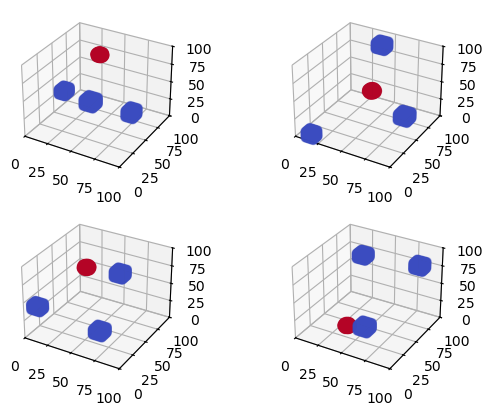

In [9]:
# Visualize the ShapeDataset output
import matplotlib.pyplot as plt


def collate_fn(batch):
    grids, features = zip(*batch)
    batched_grid = fvdb.gcat(list(grids))
    batched_features = fvdb.jcat(list(features))
    return batched_grid, batched_features


dataloader = torch.utils.data.DataLoader(ShapeDataset(), batch_size=4, collate_fn=collate_fn)
grid, features = next(iter(dataloader))
# Ground truth
gt = features.jdata[:,-1:]

fig = plt.figure()

for i in range(4):

    # ijks and ground truth for batch element i
    X_ijks_0 = grid.ijk.jdata[grid.jidx == i].detach().cpu().numpy()
    X_gt_0 = gt[grid.jidx == i].detach().cpu().numpy()

    dim = 100
    ax = fig.add_subplot(2,2,i+1, projection="3d")
    ax.set_xlim(0, dim)
    ax.set_ylim(0, dim)
    ax.set_zlim(0, dim)
    ax.scatter3D(X_ijks_0[:, 0], X_ijks_0[:, 1], X_ijks_0[:, 2], marker="o", c=X_gt_0, cmap="coolwarm", alpha=0.25)

fig.show()

##### Segmentation with `fvdb.nn.SimpleUNet`

Now that we understand the basics of sparse convolution, concatenation and training with fVDB, let's use the built-in `fvdb.nn.SimpleUNet` module to tackle our segmentation task.

`SimpleUNet` is a residual U-Net that is shipped a working, ready-to-use U-Net example in `fvdb.nn` and under-the-hood uses `SparseConv3d` and `SparseConvTranspose3d` layers with `ConvolutionPlan` objects and `ReLU` activations. Please see the [`SimpleUNet`](../fvdb/nn/simple_unet.py) source code for its implementation; all of it should be familiar to you now!


In [15]:
from fvdb.nn import SimpleUNet

SimpleUNet?

Init signature:
SimpleUNet(
    in_channels: int,
    base_channels: int,
    out_channels: int,
    channel_growth_rate: int,
    kernel_size: Union[torch.Tensor, numpy.ndarray, int, float, numpy.integer, numpy.floating, Sequence[int | float | numpy.integer | numpy.floating], torch.Size] = 3,
    downup_layer_count: int = 4,
    block_layer_count: int = 2,
    momentum: float = 0.1,
)
Docstring:     
Complete U-Net architecture for sparse voxel data processing.

Implements a residual U-Net designed specifically for sparse 3D voxel grids.
The network follows the classic U-Net structure with encoder-decoder paths,
skip connections, and residual blocks, adapted for efficient processing of
sparse volumetric data using the FVDB framework.

The architecture consists of three main stages:
1. Padding: Prepares input data with appropriate spatial and channel dimensions
2. Encoder-Decoder: Recursive downsampling and upsampling with skip connections
3. Unpadding: Produces final output in origina

Let's train this network in a simple training loop and visualize the trained predictions of the network.  Each volume has about 5% occupancy of the total volume which, if it were 'dense', would contain one million voxels.  In the 'dense' case, a batch size of 32 would mean we're training on **32 million voxels per batch** but because of the sparsity of the data, we're only training on approximately **1.6 million voxels per batch**!

In [ ]:
# Train the model!
torch.random.manual_seed(0)
# Data
batch_size = 32

dataset = ShapeDataset()
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, collate_fn=collate_fn)

# Model, Loss, Optimizer
model = SimpleUNet(
    in_channels=3,
    base_channels=16,
    out_channels=1,
    channel_growth_rate=2,
    downup_layer_count=3,
    block_layer_count=1,
).to("cuda")
loss = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
epochs = 2
with tqdm.tqdm(total=epochs) as pbar:
    for epoch in range(epochs):
        for i, (grid, features) in enumerate(dataloader):
            target = features.jdata[:,-1:]
            input_data = grid.jagged_like(features.jdata[:,:-1].contiguous())

            optimizer.zero_grad()
            y_hat = model(input_data, grid)

            l = loss(y_hat.jdata.float(), target)

            l.backward()
            optimizer.step()
            pbar.set_description(f"Epoch {epoch}, batch {i}, loss {l.item()}")
        pbar.update(1)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 4, batch 24, loss 0.01023188978433609: 100%|██████████| 5/5 [00:39<00:00,  7.96s/it] 


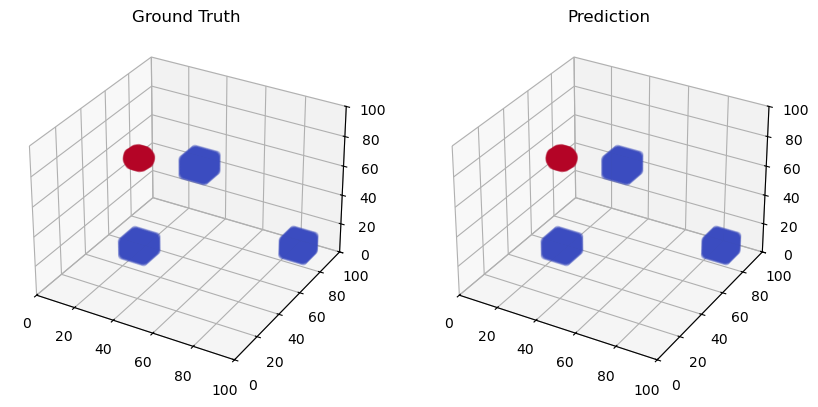

In [19]:
# Visualize the results of the trained network
import matplotlib.pyplot as plt

# Get a batch of data
grid, features = next(iter(dataloader))

# Remove the ground truth channel from the elements for the model input
input_data = grid.jagged_like(features.jdata[:,:-1].contiguous())
# Ground truth
gt = features.jdata[:,-1:]

fig = plt.figure(figsize=(10, 20))

# ijks and ground truth for batch element 0
X_ijks_0 = grid.ijk.jdata[grid.jidx == 0].detach().cpu().numpy()
X_gt_0 = gt[grid.jidx == 0].detach().cpu().numpy()


# plot input and ground truth values
dim = 100
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.set_xlim(0, dim)
ax.set_ylim(0, dim)
ax.set_zlim(0, dim)
ax.scatter3D(X_ijks_0[:, 0], X_ijks_0[:, 1], X_ijks_0[:, 2], marker="o", c=X_gt_0, cmap="coolwarm", alpha=0.25)
ax.set_title("Ground Truth")


# model inference
model.eval()
sigmoid = torch.nn.Sigmoid()
pred_data = model(input_data, grid)
pred_probs = grid.jagged_like(sigmoid(pred_data.jdata))

# predicted values for batch element 0
pred_0 = np.round(pred_probs.jdata[grid.jidx == 0].detach().cpu().numpy())

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.set_xlim(0, dim)
ax.set_ylim(0, dim)
ax.set_zlim(0, dim)
ax.scatter3D(X_ijks_0[:, 0], X_ijks_0[:, 1], X_ijks_0[:, 2], marker="o", c=pred_0, cmap="coolwarm", alpha=0.25)
ax.set_title("Prediction")

fig.show()